# 03 – Baseline model: Secondary Mushroom

**Worked on by:** Andreas Schellekens (baseline choice, class-weight experiment, test evaluation, deployable pipeline)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on the decisions in `01_eda.ipynb` and `02_data_preparation.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

The goal of this notebook is a **quick first model**: not the best one, but a working model that the deployment (API + frontend) can be built around while the other notebooks tune better models. It also sets the bar that every later model has to beat.

Imports, paths and constants. `LOKY_MAX_CPU_COUNT` silences a harmless joblib warning on Windows and must be set before scikit-learn is imported. `RANDOM_STATE` is the same value as in `02_data_preparation.ipynb`.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, get_scorer,
                             make_scorer, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

DATA_DIR = Path("Data")
MODEL_DIR = Path("models")
PREPROCESSOR_PATH = MODEL_DIR / "mushroom_preprocessor.joblib"
MODEL_PATH = MODEL_DIR / "mushroom_baseline.joblib"
METRICS_PATH = MODEL_DIR / "metrics.csv"

NOTEBOOK = "03_model_baseline"
RANDOM_STATE = 42
TARGET = "is_poisonous"
CLASS_PALETTE = {"edible": "#2a9d8f", "poisonous": "#e76f51"}  # same colours as the EDA


def data_path(split, kind):
    # Files made by 02_data_preparation.ipynb, e.g. Data/validation/mushroom_prepared_validation.csv
    return DATA_DIR / split / f"mushroom_{kind}_{split}.csv"

We load the prepared train, validation and test sets made by `02_data_preparation.ipynb`, each from its own folder. They are already imputed, `log1p`-transformed, standardised and one-hot encoded (64 features), so a scikit-learn model can use them directly.
We do **not** split again: every model notebook uses the same 3500 / 750 / 750 split, otherwise the scores in `07_model_comparison.ipynb` would not be comparable. `row_id` links every row back to the raw file.

In [2]:
def load_prepared(split):
    frame = pd.read_csv(data_path(split, "prepared"), index_col="row_id")
    return frame.drop(columns=TARGET), frame[TARGET]


X_train, y_train = load_prepared("train")
X_val, y_val = load_prepared("validation")
X_test, y_test = load_prepared("test")

print(f"Train: {X_train.shape}  |  Validation: {X_val.shape}  |  Test: {X_test.shape}")
print(f"Share poisonous – train: {y_train.mean():.1%}  |  validation: {y_val.mean():.1%}  |  test: {y_test.mean():.1%}")

Train: (3500, 64)  |  Validation: (750, 64)  |  Test: (750, 64)
Share poisonous – train: 37.9%  |  validation: 37.9%  |  test: 37.9%


## 2. Which baseline, and why?

We train two very simple models:

1. **Naive model** (`DummyClassifier`, always predicts the most frequent class = *edible*). It learns nothing from the features. Its accuracy (62%) is the floor from EDA section 3: a model that does not beat it is useless. It also shows why accuracy alone is misleading: it gets 62% right while missing **every** poisonous mushroom.
2. **Logistic regression**, our actual baseline:
   - It is fast, has almost nothing to tune, and is easy to explain: a weighted sum of the features, squashed to a probability between 0 and 1.
   - It gives a **probability**, which the web interface can show ("78% poisonous") and which lets us move the decision threshold later.
   - Its coefficients show what the model learned, so we can check it against the EDA (section 5).
   - The prepared data (standardised numericals, one-hot categoricals) is exactly what a linear model needs.

We **expect** it to be clearly worse than tree models: the EDA (section 8) showed that the classes overlap and no single feature decides edibility, so a straight decision boundary is too simple. That is fine for a baseline: it gives a lower bound, and the gap to the tuned models shows how much non-linearity is worth.

**Paths not taken for the baseline:**
- *A single decision tree*: also simple, but an unpruned tree memorises the ~2% suspected flipped labels (EDA section 9), and pruning it properly is already tuning.
- *Random forest / boosting*: these are the candidates for the tuned models (`05_model_*`). In `02_data_preparation.ipynb` a random forest was already used as a "measuring instrument" (≈ 77% accuracy, ROC-AUC ≈ 0.83 in cross-validation), which gives us a reference point.

**Metrics** (poisonous = positive class, as defined in `02_data_preparation.ipynb`):
- **Recall (poisonous)**: of all poisonous mushrooms, how many did we catch? The most important metric, because a missed poisonous mushroom can be deadly.
- **Precision (poisonous)**: of all mushrooms we call poisonous, how many really are? Low precision "only" means edible mushrooms get thrown away.
- **F1**: harmonic mean of the two.
- **ROC-AUC**: how well the predicted probabilities *rank* poisonous above edible, independent of the threshold (0.5 = random, 1 = perfect).
- **Accuracy**: reported for completeness, but always read next to the 62% floor.

## 3. Choosing the class weight

The data prep notebook showed that at the default threshold of 0.5 models catch only about half of the poisonous mushrooms. The cause is the imbalance (62/38): minimising the total number of errors pushes the model towards the majority class *edible*.

`class_weight="balanced"` makes errors on the minority class more expensive (each class gets weight `n_samples / (2 × n_in_class)`, so a poisonous mushroom counts ≈ 1.3× and an edible one ≈ 0.8×). We compare the unweighted and the balanced version.

This is a choice, so it may **not** be made on the test set. We look at it in two ways:
- **5-fold stratified cross-validation on the training set** (same folds as in the data prep notebook): five estimates, so we also see how much the scores vary.
- **The validation set**: every model is trained once on all training rows and scored on the 750 validation mushrooms it has never seen. This is the set the model notebooks use for their decisions.

The naive model is included as a reference. `zero_division=0` tells scikit-learn that precision is 0 when a model never predicts *poisonous* (the naive model) instead of printing a warning.

In [3]:
candidates = {
    "naive (always edible)": DummyClassifier(strategy="most_frequent"),
    "logistic regression": LogisticRegression(max_iter=1000),
    "logistic regression, balanced": LogisticRegression(max_iter=1000, class_weight="balanced"),
}
scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": "f1",
    "roc_auc": "roc_auc",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results, val_results = {}, {}
for name, model in candidates.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {m: scores[f"test_{m}"].mean() for m in scoring}
    cv_results[name]["accuracy_std"] = scores["test_accuracy"].std()
    fitted = clone(model).fit(X_train, y_train)
    val_results[name] = {m: get_scorer(s)(fitted, X_val, y_val) for m, s in scoring.items()}
pd.concat({"CV on train": pd.DataFrame(cv_results).T, "validation": pd.DataFrame(val_results).T}, axis=1).round(3)

CV on train                                  \
                                 accuracy recall precision     f1 roc_auc   
naive (always edible)               0.621  0.000     0.000  0.000   0.500   
logistic regression                 0.699  0.366     0.697  0.479   0.697   
logistic regression, balanced       0.647  0.589     0.531  0.558   0.697   

                                           validation                          \
                              accuracy_std   accuracy recall precision     f1   
naive (always edible)                0.000      0.621  0.000     0.000  0.000   
logistic regression                  0.014      0.712  0.401     0.712  0.514   
logistic regression, balanced        0.010      0.656  0.623     0.540  0.578   

                                       
                              roc_auc  
naive (always edible)           0.500  
logistic regression             0.703  
logistic regression, balanced   0.704

**Interpretation**
- Logistic regression clearly beats the naive model (about 70% vs. 62% accuracy, ROC-AUC 0.70 vs. 0.50), so the features do contain a learnable signal. But it stays far below the random forest reference from the data prep notebook (ROC-AUC ≈ 0.83): as expected from the EDA, a linear model is too simple for this data.
- Without class weights the model catches only about **37%** of the poisonous mushrooms in cross-validation (40% on validation). With `class_weight="balanced"` recall rises to about **59%** (62% on validation), at the cost of about 5 points of accuracy and lower precision. For mushrooms that trade-off is clearly worth it: more edible mushrooms are thrown away, but far fewer poisonous ones are eaten.
- The **ROC-AUC is the same** for both versions (0.70). That is not a coincidence: re-weighting the classes mostly shifts the intercept, which is the same as moving the decision threshold. The ranking of the mushrooms barely changes. So class weights and threshold tuning are two ways to make the same trade-off; the tuned models can choose the threshold more precisely.
- **Validation and cross-validation agree**: the same ranking of the three models, and numbers within a few points of each other (validation is slightly higher, well within the noise of 750 rows). The fold-to-fold standard deviation of accuracy is 1–1.5 points, so differences smaller than that between models should not be over-interpreted.

**Decision:** the baseline is the **balanced logistic regression**, with the default threshold of 0.5.

## 4. Final fit, validation & test evaluation

We fit the chosen model on the **whole** training set, then evaluate it on the validation set and **once** on the test set. The naive model is evaluated on the same sets as a reference.

Why both? The **validation** numbers are the ones later notebooks may *use*: `07_model_comparison.ipynb` chooses the deployed model on the validation set. The **test** numbers are only *reported*, as the final, untouched estimate of how good each model is.

The helper `evaluate` computes all metrics for one model on one set from its predicted probabilities, so every model notebook reports the same numbers in the same way. Besides the metrics we count the two error types:
- `missed_poisonous`: poisonous mushrooms predicted as edible (false negatives, the dangerous error);
- `false_alarms`: edible mushrooms predicted as poisonous (false positives, a lost meal).

The logistic regression is fitted on `X_train.to_numpy()` (the values without column names). The reason is deployment (section 6): the saved preprocessor outputs a plain NumPy array, so the model must be trained on the same kind of input to sit directly behind it. The numbers are identical either way.

In [4]:
def evaluate(name, split, y_true, p_poisonous, threshold=0.5):
    y_pred = (p_poisonous >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "notebook": NOTEBOOK,
        "split": split,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall_poisonous": recall_score(y_true, y_pred),
        "precision_poisonous": precision_score(y_true, y_pred, zero_division=0),
        "f1_poisonous": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p_poisonous),
        "missed_poisonous": fn,
        "false_alarms": fp,
    }


naive = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train.to_numpy(), y_train)
p_test = baseline.predict_proba(X_test.to_numpy())[:, 1]

results = []
for split, X_split, y_split in [("validation", X_val, y_val), ("test", X_test, y_test)]:
    results.append(evaluate("naive (always edible)", split, y_split, naive.predict_proba(X_split)[:, 1]))
    results.append(evaluate("logistic regression (balanced)", split, y_split, baseline.predict_proba(X_split.to_numpy())[:, 1]))
pd.DataFrame(results).set_index(["model", "split"]).drop(columns="notebook").round(3)

,,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
model,split,,,,,,,,
naive (always edible),validation,0.5,0.621,0.000,0.000,0.000,0.500,284,0
logistic regression (balanced),validation,0.5,0.656,0.623,0.540,0.578,0.704,107,151
naive (always edible),test,0.5,0.621,0.000,0.000,0.000,0.500,284,0
logistic regression (balanced),test,0.5,0.677,0.630,0.566,0.597,0.711,105,137


The confusion matrix shows the same result as counts. Rows are the true class, columns the prediction. The bottom-left cell is the dangerous one: poisonous mushrooms the model calls edible.

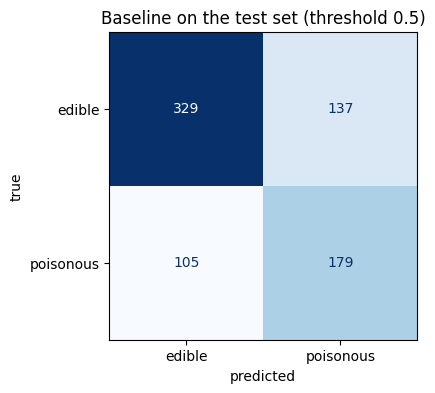

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= 0.5).astype(int), display_labels=["edible", "poisonous"],
                                        cmap="Blues", colorbar=False, ax=ax)
ax.set(title="Baseline on the test set (threshold 0.5)", xlabel="predicted", ylabel="true")
plt.show()

**Interpretation**
- The scores on the three kinds of unseen data are close: accuracy 0.65 (CV) / 0.66 (validation) / 0.68 (test), recall 0.59 / 0.62 / 0.63, ROC-AUC 0.70 / 0.70 / 0.71. So the model is not overfitting, and the estimates from the training set were reliable. That is expected for a linear model with 64 features and 3500 rows.
- Of the 284 poisonous test mushrooms, the model still calls **105 edible** (37%). As a real mushroom advisor this model would be dangerous. The tuned models must reduce this number above all.
- It also throws away 137 of the 466 edible mushrooms. Because we weighted the classes, the model now makes more false alarms than misses, which is the direction we want.
- The naive model shows why we never report accuracy alone: 62% accuracy, and 0% of the poisonous mushrooms caught.

## 5. What did the model learn?

Because all numerical features are standardised and the categoricals are 0/1 columns, the coefficients are on a comparable scale. A **positive** coefficient pushes the prediction towards *poisonous*, a negative one towards *edible*. We plot the 10 strongest in each direction and compare them with the EDA.

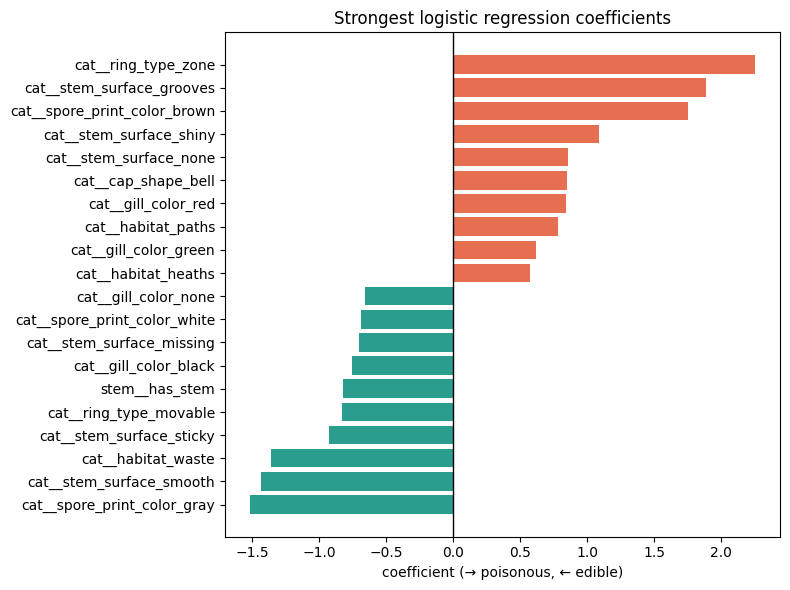

Numerical features and has_stem:
stem__has_stem      -0.824
num__stem_width     -0.223
num__stem_height    -0.106
num__cap_diameter   -0.059


In [6]:
coefs = pd.Series(baseline.coef_[0], index=X_train.columns).sort_values()
top = pd.concat([coefs.head(10), coefs.tail(10)])

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[CLASS_PALETTE["poisonous"] if v > 0 else CLASS_PALETTE["edible"] for v in top])
ax.axvline(0, c="k", lw=1)
ax.set(title="Strongest logistic regression coefficients", xlabel="coefficient (→ poisonous, ← edible)")
plt.tight_layout()
plt.show()

print("Numerical features and has_stem:")
print(coefs[[c for c in coefs.index if not c.startswith("cat__")]].round(3).to_string())

**Interpretation**
- The strongest signals are the (almost) pure categories found in EDA section 7.1: `ring_type = zone`, `stem_surface = grooves / shiny / none`, `spore_print_color = brown` and `habitat = paths` push towards poisonous; `stem_surface = smooth`, `habitat = waste`, `spore_print_color = gray` and `ring_type = movable` towards edible. The model learned what the data shows, which makes us trust the pipeline.
- The numerical features also agree with the EDA: `has_stem` has a negative coefficient (a stem points towards edible; stemless mushrooms are 92% poisonous, EDA 6.1), and all three size measures are negative (poisonous mushrooms are slightly smaller, EDA 6.4). Their coefficients are small, in line with the small effect sizes found there.
- `stem_surface = missing` points towards edible, which confirms EDA section 5.2: for this column, *being missing* carries information, and our `"missing"` category lets the model use it.
- Most of these strong categories are **small** (tens of rows). For the large majority of mushrooms (e.g. `ring_type = none`, 73% of the data) no single category helps, and a linear model can only add up the separate effects. It cannot learn combinations such as "small cap **and** no ring **and** woods". That is exactly what tree models can do, and why we expect them to do much better.

## 6. Saving the model for deployment

The API will receive a mushroom as *readable* values (e.g. `cap_shape = "convex"`), not as 64 standardised one-hot columns. So we do not only save the logistic regression, but a **pipeline**: the fitted preprocessor from `02_data_preparation.ipynb` followed by the fitted model. The API then only has to apply the cleaning of the data prep notebook (sections 2–5: labels, stem rule, `"missing"`) and call `pipeline.predict_proba(...)`.

Nothing is refitted here: both steps were already fitted on the training set. The preprocessor outputs the 64 columns in the same order as the prepared CSVs, and the model was trained on those values (section 4), so the two fit together.

We check that this works: the pipeline, fed with the **cleaned** test rows from `Data/test/mushroom_cleaned_test.csv`, must give exactly the same probabilities as the model on the prepared test set. Both files have the same `row_id`s in the same order.

In [7]:
preprocessor = joblib.load(PREPROCESSOR_PATH)
assert list(preprocessor.get_feature_names_out()) == list(X_train.columns)
deploy_pipeline = Pipeline([("preprocess", preprocessor), ("model", baseline)])

cleaned_test = pd.read_csv(data_path("test", "cleaned"), index_col="row_id")
assert cleaned_test.index.equals(X_test.index)

p_pipeline = deploy_pipeline.predict_proba(cleaned_test[list(preprocessor.feature_names_in_)])[:, 1]
assert np.allclose(p_pipeline, p_test), "Pipeline output differs from the model on the prepared data"

joblib.dump(deploy_pipeline, MODEL_PATH)
print(f"Saved {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024:.0f} KB)")
print("Input columns the API must provide:", list(preprocessor.feature_names_in_))

Saved models\mushroom_baseline.joblib  (8 KB)
Input columns the API must provide: ['cap_diameter', 'stem_height', 'stem_width', 'has_stem', 'spore_print_color', 'gill_color', 'habitat', 'season', 'ring_type', 'cap_shape', 'stem_surface']


## 7. Storing the metrics

The assignment asks us to keep the metrics of every model so they can be compared. Every model notebook adds its results to one shared file, `models/metrics.csv`, which `07_model_comparison.ipynb` reads. There is one row per model, set and threshold: the column `split` says whether a row was measured on the **validation** set (used to choose the deployed model) or the **test** set (the final numbers). If a notebook is run again, its old rows are replaced instead of duplicated.

In [8]:
new_rows = pd.DataFrame(results)
if METRICS_PATH.exists():
    metrics = pd.read_csv(METRICS_PATH)
    metrics = pd.concat([metrics[metrics["notebook"] != NOTEBOOK], new_rows], ignore_index=True)
else:
    metrics = new_rows
metrics.to_csv(METRICS_PATH, index=False)
metrics.round(3)

,model,notebook,split,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
0,PyCaret random forest (default),04_model_automl,validation,0.500,0.803,0.648,0.793,0.713,0.818,100,48
1,PyCaret random forest (default),04_model_automl,test,0.500,0.785,0.606,0.778,0.681,0.838,112,49
2,random forest (tuned),05a_model_random_forest,validation,0.500,0.800,0.634,0.796,0.706,0.817,104,46
3,"random forest (tuned, recall 0.90)",05a_model_random_forest,validation,0.161,0.564,0.901,0.461,0.610,0.817,28,299
4,random forest (tuned),05a_model_random_forest,test,0.500,0.795,0.613,0.798,0.693,0.842,110,44
5,"random forest (tuned, recall 0.90)",05a_model_random_forest,test,0.161,0.579,0.930,0.471,0.626,0.842,20,296
6,gradient boosting (tuned),05b_model_gradient_boosting,validation,0.500,0.799,0.634,0.793,0.705,0.819,104,47
7,"gradient boosting (tuned, recall 0.90)",05b_model_gradient_boosting,validation,0.139,0.573,0.901,0.467,0.615,0.819,28,292
8,gradient boosting (tuned),05b_model_gradient_boosting,test,0.500,0.808,0.623,0.827,0.711,0.847,107,37
9,"gradient boosting (tuned, recall 0.90)",05b_model_gradient_boosting,test,0.139,0.576,0.940,0.470,0.627,0.847,17,301


## 8. Conclusion & next steps

- **Baseline:** logistic regression with `class_weight="balanced"`. On the test set: accuracy ≈ 68%, recall (poisonous) ≈ 0.63, ROC-AUC ≈ 0.71 (validation: 66%, 0.62, 0.70). Better than the naive 62%, but it still misses more than a third of the poisonous mushrooms.
- **Class weights matter:** they raised poisonous recall from ≈ 0.37 to ≈ 0.59 in cross-validation (0.40 to 0.62 on validation) without changing the ROC-AUC. They move the decision threshold; they do not make the model better at ranking.
- **Linear is not enough:** the model rediscovers the strong categories from the EDA, but cannot combine features. The random forest from the data prep notebook already reaches ROC-AUC ≈ 0.83 without tuning.
- **Deployable:** `models/mushroom_baseline.joblib` (preprocessor + model) takes cleaned, readable input, so the API and frontend can be built now. When a better model is ready, only this file needs to be replaced.
- **Metrics:** `models/metrics.csv` now has a validation row and a test row per model.

**Next steps**
- `04_model_automl.ipynb`: PyCaret comparison of many models on the cleaned data (same split).
- `05_model_*.ipynb`: tune the most promising non-linear models with cross-validation on the training set, and choose the **decision threshold** on the validation set (target: much higher poisonous recall at acceptable precision). Test the remaining open question from the data prep notebook there: removing suspected flipped labels (imputation and `spore_print_color` were already answered in 02, section 9.2).